# Exploratory Data Analysis
**EDA** for short is investigation of the data in order to better understand the data before making any assumptions and summarize its main characteristics: identify obvious errors, understand patterns within the data, detect outliers or anomalous events, and find interesting relations among the variables.

EDA rely heavily on **statistics** and **visualization** methods.


In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

## Dataset
On April 15, 1912, the largest passenger liner ever made collided with an iceberg during her maiden voyage. When the Titanic sank it killed 1502 out of 2224 passengers and crew. One of the reasons that the shipwreck resulted in such loss of life was that there were not enough lifeboats for the passengers and crew. Although there was some element of luck involved in surviving the sinking, some groups of people were more likely to survive than others.

The titanic dataset contains data for 887 of the real Titanic passengers. Each row represents one person.


VARIABLE DESCRIPTIONS:

| Variable |                 Definition                 |                       Key                      |   |   |
|:--------:|:------------------------------------------:|:----------------------------------------------:|---|---|
| survival | Survival                                   | 0 = No, 1 = Yes                                |   |   |
| pclass   | Ticket class                               | 1 = 1st, 2 = 2nd, 3 = 3rd                      |   |   |
| sex      | Sex                                        |                                                |   |   |
| Age      | Age in years (is estimated)                              |                                                |   |   |
| sibsp    | # of siblings / spouses aboard the Titanic |                                                |   |   |
| parch    | # of parents / children aboard the Titanic |                                                |   |   |
| ticket   | Ticket number                              |                                                |   |   |
| fare     | Passenger fare                             |                                                |   |   |
| cabin    | Cabin number                               |                                                |   |   |
| embarked | Port of Embarkation                        | C = Cherbourg, Q = Queenstown, S = Southampton |



let's load it:

In [ ]:
!wget -q --no-check-certificate 'https://docs.google.com/uc?export=download&id=1jpaNUBQ2ehkIB8nNP1XxyJjNtpCdvkTL' -O "data.zip"
!unzip -q "data.zip"

In [60]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
df = pd.concat([train_df, test_df])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.loc[1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
1,893,NaN,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


In [ ]:
df.iloc[1]

PassengerId                                                    2
Survived                                                     1.0
Pclass                                                         1
Name           Cumings, Mrs. John Bradley (Florence Briggs Th...
Sex                                                       female
Age                                                         38.0
SibSp                                                          1
Parch                                                          0
Ticket                                                  PC 17599
Fare                                                     71.2833
Cabin                                                        C85
Embarked                                                       C
Name: 1, dtype: object

what's happening here?!

`loc` function return rows with index equals to 1.

`iloc` function return row located at position 1.

The main distinction between `loc` and `iloc`
* loc gets rows (and/or columns) with particular **index**.
* iloc gets rows (and/or columns) at integer **locations** and always ranges from 0 to (length - 1)

Because we merge two dataframes without resetting index, some rows have the same index.

It apperes that we have a monotonic integer index. However, that is not always the case.

Beware when you droping a row in non-monotonic index case:
- degrades performance from O(log n) to O(n) for lookups, as pandas cannot use binary search and must scan the index.
- Ambiguity in slicing.
- When you create a DataFrame, Pandas tries to store the data in a contiguous block of memory for speed. To find a specific row, it uses an internal Index Engine. In a Non-Monotonic Index: The engine has to maintain a complex mapping because the data is scattered. For example, if your index is [10, 2, 55, 3], the engine stores a map: Label 10 is at Position 0, Label 2 is at Position 1...

In [ ]:
df.loc[1: 10]

KeyError: 'Cannot get left slice bound for non-unique label: 1'

In [61]:
df = df.reset_index()

In [62]:
df.loc[1]

,1
index,1
PassengerId,2
Survived,1.0
Pclass,1
Name,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
Sex,female
Age,38.0
SibSp,1
Parch,0
Ticket,PC 17599


In [63]:
df = df.drop(['index'], axis=1)

It is important to get a sense of how many variables and cases there are, the data types of the variables, etc...

In [ ]:
df.columns

Index(['index', 'PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age',
       'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df.shape

(1309, 13)

In [ ]:
df.dtypes

index            int64
PassengerId      int64
Survived       float64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

By default, pandas will try to infer the dtype of each column based on the data it contains. However, this can sometimes result in unexpected or incorrect dtypes. Therefore, it is important to manually set dtypes when working with large datasets or when the data types are known in advance.

There is no magic involved in the type inference. At first, pandas try to convert all values to an integer. If an error occurs, then pandas jumps to the next data type. The last data type is called an object, which is simply an array of strings. Notice how both `Survived` and `Pclass` considered numerical attributes, although they should be categorical.

**Fallback**: If a column contains even a single string in a column of integers, the algorithm defaults the entire column to object (to avoid data loss).


In data analysis, variables that split records into a fixed number of unique categories, such as Sex, are known as categorical variables or **qualitative** attributes. In contrast numeric variables are collectively referred to as **quantitative**.

However, the properties of an attribute need not to be the same as the properties of the values used to measure it.
In other words, the values used to represent an attribute may have properties that are not properties of the attribute itself, and vice versa.

For example, in our dataset, ID and Age, while it is reasonable to talk about the average age of a passenger, it makes no sense to talk about the average passenger ID. Nonetheless, the only aspect of passengers that we want to capture with the ID attribute is that they are distinct.

As for the fare attribute, the properties of the integers used to represent fare are very much the properties of the attribute. Even so, the correspondence is not complete since, for example, fares have a maximum, while integers do not.


**Pandas types**:

| Pandas dtype | Python type | Usage |
| :--- | :--- | :--- |
| **object** | str or mixed | Text or mixed numeric and non-numeric values |
| **int64** | int | Integer numbers |
| **float64** | float | Floating point numbers |
| **bool** | bool | True/False values |
| **datetime64** | NA | Date and time values |
| **timedelta[ns]** | NA | Differences between two datetimes |
| **category** | NA | Finite list of text values |

Now let's change the type of variables with incorrect data type:

In [64]:
df = df.astype({'Survived': 'object', 'Pclass': 'object'})
df.dtypes

,0
PassengerId,int64
Survived,object
Pclass,object
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


But the **category** type requires less memory to store the same amount of data compared to object type or int type data. This is because category data type stores only the unique categories and assigns integer codes to each category, while object data type stores the entire string values.

Use category if you have a column with many repetitions (low cardinality).

## Statistics of data

For data preprocessing to be successful, it is essential to have an overall picture of your data.

Basic statistical descriptions can be used to identify properties of the data and highlight which data values
should be treated as noise or outliers.


Let's play with the categorical attributes first:

### Categorical Values Analysis

In [41]:
# categorical columns
df_cat = df.select_dtypes(include=['object'])
cat_columns = df_cat.columns.drop(['Name']).tolist() # Name is not a category but rather a free text form column
cat_columns

['Survived', 'Pclass', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [42]:
types = {col: 'category' for col in cat_columns} # Always try to use comperhenstions for efficiency and the ease of syntax
df_cat = df_cat.astype(types)
df_cat.dtypes

,0
Survived,category
Pclass,category
Name,object
Sex,category
Ticket,category
Cabin,category
Embarked,category


In [ ]:
df_cat.nunique()

,0
Survived,2
Pclass,3
Name,1307
Sex,2
Ticket,929
Cabin,186
Embarked,3


<font color='orange'>There is something interesting here</font>, ticket column has 929 unique values while it should be 1307 unique values (a unique tickets for every person).

Many passengers used the same ticket.

Maybe null values in the reason, to check how many null (NaN) values are there:

In [ ]:
df['Ticket'].isnull().sum()

np.int64(0)

The Null values is not the reason, let's try to understand what cause that by analysis ticket values:

In [ ]:
pd.Series(df['Ticket'].unique())

,0
0,A/5 21171
1,PC 17599
2,STON/O2. 3101282
3,113803
4,373450
...,...
924,365237
925,347086
926,A.5. 3236
927,SOTON/O.Q. 3101262


To discover if there is any cheating or groups can take the same tickets we will show if there is any relation between surviving and persons got the same ticket count:

In [ ]:
df['Ticket'].value_counts()

CA. 2343        11
CA 2144          8
1601             8
PC 17608         7
S.O.C. 14879     7
                ..
113792           1
36209            1
323592           1
315089           1
359309           1
Name: Ticket, Length: 929, dtype: int64

Notice how the index of the series is the `Ticket` and the value is the number of occurrences.

In [ ]:
df.groupby('Ticket')

In [ ]:
ticket_count = df.groupby('Ticket')['Ticket'].transform('count')
ticket_count

,Ticket
0,1
1,2
2,1
3,2
4,1
...,...
1304,1
1305,3
1306,1
1307,1


In [ ]:
df['ticket_count'] = ticket_count # same index hence the assignment will not result inconsistent data
df.head()

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,ticket_count
0,0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


Plotly is an open source graphic library provides interactive charts.

Usually we use plotly **Express** to draw, but if plotly express does not provide a good starting point, it is also possible to use the more generic **go.[chart_name]** class from **plotly.graph_objects** as the case bellow, where we need to draw 2 histograms in the same figure:

Let's show the **histogram** of the ticket count:

A **histogram** is a graphical representation used in statistics to show the distribution of continuous numerical data. The data is grouped into class intervals (bins), and the height of each bar shows the frequency of values.

A histogram helps us understand the shape of the data, such as peaks, spread, and whether the data is symmetric or skewed.

In [ ]:
layout_options = {
    'paper_bgcolor':"#383838",
    'plot_bgcolor':'#383838',
    'title_font': dict(color='white'),
    'legend_font': dict(color='white'),
    'yaxis':dict(color="white"),
    'xaxis':dict(color="white")
    }

In [ ]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=df[df['Survived'] == 1]['ticket_count'].values,
                           name="Survived", marker_color='#EB89B5'))
fig.add_trace(go.Histogram(x=df[df['Survived'] == 0]['ticket_count'].values,
                           name="Died", marker_color='#330C73'))
fig.update_layout(**layout_options)
fig.show()

Groups with 2,3 and 4 members had a higher survival rate. Passengers who travel alone has the lowest survival rate. After 4 group members, survival rate decreases drastically. There is no direct relation but seems that the reason is not the cheating.

Let's check the recodes with the most frequent ticket (CA. 2343 that repeated 11 times):

In [ ]:
df[df['Ticket'] == 'CA. 2343']

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,ticket_count
159,159,160,0.0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S,11
180,180,181,0.0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S,11
201,201,202,0.0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S,11
324,324,325,0.0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S,11
792,792,793,0.0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S,11
846,846,847,0.0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S,11
863,863,864,0.0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S,11
1079,188,1080,NaN,3,"Sage, Miss. Ada",female,NaN,8,2,CA. 2343,69.55,NaN,S,11
1233,342,1234,NaN,3,"Sage, Mr. John George",male,NaN,1,9,CA. 2343,69.55,NaN,S,11
1251,360,1252,NaN,3,"Sage, Master. William Henry",male,14.5,8,2,CA. 2343,69.55,NaN,S,11


In [ ]:
df[df['Ticket'] == 'CA 2144']

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,ticket_count
59,59,60,0.0,3,"Goodwin, Master. William Frederick",male,11.0,5,2,CA 2144,46.9,NaN,S,8
71,71,72,0.0,3,"Goodwin, Miss. Lillian Amy",female,16.0,5,2,CA 2144,46.9,NaN,S,8
386,386,387,0.0,3,"Goodwin, Master. Sidney Leonard",male,1.0,5,2,CA 2144,46.9,NaN,S,8
480,480,481,0.0,3,"Goodwin, Master. Harold Victor",male,9.0,5,2,CA 2144,46.9,NaN,S,8
678,678,679,0.0,3,"Goodwin, Mrs. Frederick (Augusta Tyler)",female,43.0,1,6,CA 2144,46.9,NaN,S,8
683,683,684,0.0,3,"Goodwin, Mr. Charles Edward",male,14.0,5,2,CA 2144,46.9,NaN,S,8
1030,139,1031,NaN,3,"Goodwin, Mr. Charles Frederick",male,40.0,1,6,CA 2144,46.9,NaN,S,8
1031,140,1032,NaN,3,"Goodwin, Miss. Jessie Allis",female,10.0,5,2,CA 2144,46.9,NaN,S,8


In [ ]:
df[df['Ticket'] == '1601']

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,ticket_count
74,74,75,1.0,3,"Bing, Mr. Lee",male,32.0,0,0,1601,56.4958,NaN,S,8
169,169,170,0.0,3,"Ling, Mr. Lee",male,28.0,0,0,1601,56.4958,NaN,S,8
509,509,510,1.0,3,"Lang, Mr. Fang",male,26.0,0,0,1601,56.4958,NaN,S,8
643,643,644,1.0,3,"Foo, Mr. Choong",male,NaN,0,0,1601,56.4958,NaN,S,8
692,692,693,1.0,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S,8
826,826,827,0.0,3,"Lam, Mr. Len",male,NaN,0,0,1601,56.4958,NaN,S,8
838,838,839,1.0,3,"Chip, Mr. Chang",male,32.0,0,0,1601,56.4958,NaN,S,8
930,39,931,NaN,3,"Hee, Mr. Ling",male,NaN,0,0,1601,56.4958,NaN,S,8


There is interesting finding here: the passengers that traveled by the same ticket were from the same family and traveled in the 3th class.

Let's check the recodes with repeated tickets form 2 to 4 times:

In [ ]:
tickets_groups = df[(df['ticket_count'] >= 2) & (df['ticket_count'] <= 4)].set_index(['Ticket', 'index']).sort_index() # Multilevel index
tickets_groups

PassengerId Survived Pclass  \
Ticket      index                                
110152      257            258      1.0      1   
            504            505      1.0      1   
            759            760      1.0      1   
110413      262            263      0.0      1   
            558            559      1.0      1   
...                        ...      ...    ...   
W./C. 6607  888            889      0.0      3   
W.E.P. 5734 14             906      NaN      1   
            92              93      0.0      1   
WE/P 5735   540            541      1.0      1   
            745            746      0.0      1   

                                                                Name     Sex  \
Ticket      index                                                              
110152      257                                 Cherry, Miss. Gladys  female   
            504                                Maioni, Miss. Roberta  female   
            759    Rothes, the Countess. of (Lucy Noel Martha Dye...  female   
110413      262                                    Taussig, Mr. Emil    male   
            558               Taussig, Mrs. Emil (Tillie Mandelbaum)  female   
...                                                              ...     ...   
W./C. 6607  888             Johnston, Miss. Catherine Helen "Carrie"  female   
W.E.P. 5734 14     Chaffee, Mrs. Herbert Fuller (Carrie Constance...  female   
            92                           Chaffee, Mr. Herbert Fuller    male   
WE/P 5735   540                              Crosby, Miss. Harriet R  female   
            745                         Crosby, Capt. Edward Gifford    male   

                    Age  SibSp  Parch    Fare Cabin Embarked  ticket_count  
Ticket      index                                                           
110152      257    30.0      0      0  86.500   B77        S             3  
            504    16.0      0      0  86.500   B79        S             3  
            759    33.0      0      0  86.500   B77        S             3  
110413      262    52.0      1      1  79.650   E67        S             3  
            558    39.0      1      1  79.650   E67        S             3  
...                 ...    ...    ...     ...   ...      ...           ...  
W./C. 6607  888     NaN      1      2  23.450   NaN        S             4  
W.E.P. 5734 14     47.0      1      0  61.175   E31        S             2  
            92     46.0      1      0  61.175   E31        S             2  
WE/P 5735   540    36.0      0      2  71.000   B22        S             2  
            745    70.0      1      1  71.000   B22        S             2  

[475 rows x 12 columns]

The **MultiIndex** is the hierarchical analogue of the standard Index object which typically stores the axis labels in pandas objects. You can think of MultiIndex as an array of tuples where each tuple is unique.

You can access it as type: df.loc[('level2', 'level2')]

In [ ]:
tickets_groups[['Name',
                'Pclass',
                'Cabin',
                'ticket_count']].head(10) # Notice how head would give us 10 observations regardless of the multilevel index

Name Pclass Cabin  \
Ticket index                                                                   
110152 257                                 Cherry, Miss. Gladys      1   B77   
       504                                Maioni, Miss. Roberta      1   B79   
       759    Rothes, the Countess. of (Lucy Noel Martha Dye...      1   B77   
110413 262                                    Taussig, Mr. Emil      1   E67   
       558               Taussig, Mrs. Emil (Tillie Mandelbaum)      1   E67   
       585                                  Taussig, Miss. Ruth      1   E68   
110465 110                       Porter, Mr. Walter Chamberlain      1  C110   
       475                          Clifford, Mr. George Quincy      1   A14   
110813 236                             Warren, Mr. Frank Manley      1   D37   
       366     Warren, Mrs. Frank Manley (Anna Sophia Atkinson)      1   D37   

              ticket_count  
Ticket index                
110152 257               3  
       504               3  
       759               3  
110413 262               3  
       558               3  
       585               3  
110465 110               2  
       475               2  
110813 236               2  
       366               2

Okay, still the observation valid, but why not all members had the same last name?

It seems that many passengers travelled along with groups. Those groups consist of friends, nannies, maids and etc.

In [ ]:
df['Sex'].isnull().sum()

0

A **pie chart** is a circular data visualization tool that divides a circle (the whole) into sectors (slices) to illustrate numerical proportions, percentages, or parts-to-whole relationships.

Arguments:
- names: Defines the categories or text labels for each sector.
- values: Sets the numerical value for each sector, which determines its size in the pie.

In [ ]:
fig = px.pie(df, names='Sex', title='Distribution of Gender')
fig.show()

In [ ]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Survived", "Not Survived"),
                    specs=[[{"type": "domain"}, {"type": "domain"}]])

survived_sex = df[df['Survived'] == 1]['Sex'].value_counts()
fig.add_trace(go.Pie(
    labels=survived_sex.index,
    values=survived_sex.values,
    name="Survived",
), row=1, col=1)

died_sex = df[df['Survived'] == 0]['Sex'].value_counts()
fig.add_trace(go.Pie(
    labels=died_sex.index,
    values=died_sex.values,
    name="Not Survived",
), row=1, col=2)

fig.update_layout(
    paper_bgcolor='#e8f4f0',
    showlegend=True
)

fig.show()

In [ ]:
stat = df[["Sex", "Survived", 'Name']].copy()
stat['Survived'] = stat['Survived'].map({1: 'Lived', 0: 'Died'})
stat = stat.groupby(['Survived', 'Sex']).count()
stat

Name
Survived Sex         
Died     female    81
         male     468
Lived    female   233
         male     109

In [ ]:
stat = stat.rename({'Name': 'count'}, axis=1)
# axis{0 or ‘index’, 1 or ‘columns’}, default 0
# Axis to target with mapper. Can be either the axis name (‘index’, ‘columns’) or number (0, 1). The default is ‘index’.
stat

count
Survived Sex          
Died     female     81
         male      468
Lived    female    233
         male      109

Why we choose the Name column above?

Note: .count() only counts non-null values in a specific column.

Notice the differnt between genders count between survived and name column:

In [ ]:
sex_stat = df[["Sex",
               "Survived",
               'Name']].groupby(['Sex']).count()
sex_stat

,Survived,Name
Sex,,
female,314,466
male,577,843


To understand the difference notice:

In [ ]:
df_cat.groupby(['Survived', 'Sex']).count()

Pclass  Name  Ticket  Cabin  Embarked
Survived Sex                                          
0.0      female      81    81      81      6        81
         male       468   468     468     62       468
1.0      female     233   233     233     91       231
         male       109   109     109     45       109

The difference in the columns due to null values in survived variable, and that's why we choose a column with no null values (name).

Women (Sex=female) were more likely to have survived. ~74% female passenger survived while only ~19% male passenger survived.

In [ ]:
stat = df[["Sex", "Survived"]].copy()
stat.groupby(['Sex']).mean().rename({'Survived': 'ratio'}, axis=1)

,ratio
Sex,
female,0.742038
male,0.188908


Same results as the survival ratio above! Think Why?

We can visualize our results using `Sunburst` chart, which is essentially an extended version of `Pie` chart, where Pie charts show a single level of data, while sunburst charts use concentric rings to display multi-level, hierarchical, or nested data.

In [ ]:
plot_data = df.copy()
plot_data['Survived'] = plot_data['Survived'].map({1: 'Survived', 0: 'Died'})
fig = px.sunburst(plot_data, path=['Sex', 'Survived'])

# textinfo:
# Type: flaglist string. Any combination of "label", "text", "value", "percent" joined with a "+" OR "none".
# Examples: "label", "text", "label+text", "label+text+value", "none"
# Determines which trace information appear on the graph.
fig.update_traces(textinfo='label+percent parent',
                  textfont=dict(color='white'),
                  rotation=120)
fig.update_layout(**layout_options)
fig.show()

ValueError: ('Non-leaves rows are not permitted in the dataframe \n', Sex         female
Survived          
Name: 892, dtype: object, 'is not a leaf.')

Why?
Survived column has null values.

**The Tree Construction (The "Path" Logic):**

The algorithm starts at a central point (the root) and moves outward layer by layer.

Step A: Grouping by Level 0: It looks at the first item in your path (Sex). It groups all rows by 'male' and 'female'. These become the innermost circle.

Step B: Branching to Level 1: Within the 'female' group, it then looks at the second item in your path (Survived). It creates sub-sectors for 'Survived' and 'Died'.

The Leaf Rule: Every row must eventually end at a "leaf" (the outermost level you defined). If a row stops at Sex but doesn't have a value for Survived, the algorithm gets confused because it doesn't know whether to draw a "branch" or a "leaf."

In [ ]:
plot_data = df.dropna(subset='Survived') # Dropping null is an esensial step before type conversion
plot_data['Survived'] = plot_data['Survived'].map({1: 'Survived', 0: 'Died'})
fig = px.sunburst(plot_data, path=['Sex', 'Survived'])
fig.update_traces(textinfo='label+percent parent',
                  textfont=dict(color='white'),
                  rotation=120)
fig.update_layout(**layout_options)
fig.show()

/tmp/ipykernel_30001/2020853938.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
df['Embarked'].isnull().sum()

np.int64(2)

In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
S,914
C,270
Q,123


It looks like there are only two null values( ~ 0.22 %) in the Embarked feature, we will handle them later...

Let's see if there is any relation between embarked and surviving:

When you need to visualize categorical variable values, you use **bar charts** instead of the histogram.

**Bar chart vs histogram:**

Histograms visualize the distribution of continuous numerical data using touching bars to show frequency, while bar graphs compare distinct, separate categories using spaced bars. Histograms show trends over numerical ranges (e.g., 0-10, 10-20), whereas bar graphs compare specific, independent items (e.g., red, blue, green).

In [ ]:
plot_data = df.groupby(['Embarked', 'Survived'], as_index=False).count()[['Embarked', 'Survived', 'PassengerId']].rename({'PassengerId': 'count'}, axis=1).astype({'Survived': 'bool'})
plot_data

,Embarked,Survived,count
0,C,False,75
1,C,True,93
2,Q,False,47
3,Q,True,30
4,S,False,427
5,S,True,217


In [ ]:
fig = px.bar(plot_data, x='Embarked', y='count', color='Survived',
             color_discrete_map={False: px.colors.qualitative.Plotly[1],
                                 True: px.colors.qualitative.Plotly[0]}, barmode='group')
fig.update_layout(**layout_options)
fig.show()

Approximately half of passengers with embarked='S' and 'Q didn't survive, but there is no direct relation between surviving and embarked feature.

In [ ]:
plot_data = df.groupby(['Pclass', 'Survived'], as_index=False).count()[['Pclass', 'Survived', 'PassengerId']].rename({'PassengerId': 'count'}, axis=1).astype({'Survived': 'bool'})

In [ ]:
fig = px.bar(plot_data, x='Pclass', y='count', color='Survived',
             color_discrete_map={False: px.colors.qualitative.Plotly[1],
                                 True: px.colors.qualitative.Plotly[0]}, barmode='group')
fig.update_layout(**layout_options)
fig.show()

In [ ]:
df[['Pclass', 'Survived']].groupby(['Pclass']).mean().sort_values(by='Survived', ascending=False)

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


The first-class passengers (Pclass=1) were more likely to have survived (63% of the first-class passengers survived).

In [38]:
df['Cabin'].isnull().sum()

np.int64(1014)

In [ ]:
print("Cabin missing: " + str(df.Cabin.isnull().sum() / len(df.Cabin)))

Cabin missing: 0.774637127578304


Approximately 77% of Cabin feature is missing, it's too much!

In [ ]:
plot_data = df.groupby(['Cabin', 'Survived']).count()[['PassengerId']].rename({'PassengerId': 'count'}, axis=1).reset_index()
plot_data

,Cabin,Survived,count
0,A10,0.0,1
1,A14,0.0,1
2,A16,1.0,1
3,A19,0.0,1
4,A20,1.0,1
...,...,...,...
158,F38,0.0,1
159,F4,1.0,2
160,G6,0.0,2
161,G6,1.0,2


In [ ]:
fig = px.bar(plot_data, x='Cabin', y='count', color='Survived')
fig.update_layout(**layout_options)
fig.show()

No direct Relation. can we check the relation when only taking the first letter of the cabin in consideration? let's try:

In [ ]:
plot_data['Cabin'] = plot_data['Cabin'].dropna().str.slice(0, 1)
plot_data.head()

,Cabin,Survived,count
0,A,False,1
1,A,False,1
2,A,True,1
3,A,False,1
4,A,True,1


In [ ]:
plot_data = plot_data.groupby(['Cabin', 'Survived']).count().reset_index()
# we do that to avoid stack bars with incorrect count
plot_data

,Cabin,Survived,count
0,A,False,8
1,A,True,7
2,B,False,12
3,B,True,24
4,C,False,21
5,C,True,29
6,D,False,7
7,D,True,19
8,E,False,8
9,E,True,17


In [ ]:
fig = px.bar(plot_data, x='Cabin', y='count', color='Survived')
fig.update_layout(**layout_options)
fig.show()

No obvious relation, let's check if there is a relation between class and cabin:

In [ ]:
plot_data = df.copy()
plot_data['Cabin'] = plot_data['Cabin'].dropna().str.slice(0, 1)
plot_data = plot_data.groupby(['Cabin', 'Pclass']).count()[['PassengerId']].rename({'PassengerId': 'count'}, axis=1).reset_index()
plot_data

,Cabin,Pclass,count
0,A,1,22
1,B,1,65
2,C,1,94
3,D,1,40
4,D,2,6
5,E,1,34
6,E,2,4
7,E,3,3
8,F,2,13
9,F,3,8


In [22]:
plot_data['Pclass'] = plot_data['Pclass'].map({1: '1th class', 2: "2nd class", 3: "3rd class"})
# beacuse group barmodel will not work with integer values

In [24]:
fig = px.bar(plot_data, x='Cabin', y='count', color='Pclass', barmode='group') # by default barmode is 'stack'
fig.update_layout(**layout_options)
fig.show()

In another way:

In [25]:
df['Cabin'] = df['Cabin'].astype(str).str.slice(0, 1)

In [27]:
fig = px.sunburst(df, path=['Pclass', 'Cabin'])
fig.update_traces(textinfo='label+percent entry',
                  textfont=dict(color='white'),
                  rotation=120)
fig.update_layout(**layout_options)
fig.show()

What is the n??

In [28]:
fig = px.sunburst(df[df['Cabin'] != 'n'], path=['Pclass', 'Cabin'])
fig.update_traces(textinfo='label+percent entry',
                  textfont=dict(color='white'),
                  rotation=120)
fig.update_layout(**layout_options)
fig.show()

A, B, C and T cabins were only for 1st class passengers. T has only one preson.

D cabin was for 1st and 2ed classes passengers.

F cabin was for 3th and 2ed classes passengers.

G cabin was only for 3th class passengers.

E cabin was for all classes.


Instead of check null values in each column alone, we can do that:

In [43]:
info_df = pd.DataFrame()
info_df['missing_val'] = df_cat.isnull().sum()
info_df['missing_val_ratio'] = (info_df['missing_val'] / df_cat.shape[0] * 100).round().astype(int)
info_df

,missing_val,missing_val_ratio
Survived,418,32
Pclass,0,0
Name,0,0
Sex,0,0
Ticket,0,0
Cabin,1014,77
Embarked,2,0


When we do .str and slice the cabin values, null values are converted to string and sliced, you must pay attention when you check and drop the null values to avoid the `Stringified Nulls`.

In [ ]:
df_cat.describe()

,Survived,Pclass,Name,Sex,Ticket,Cabin,Embarked
count,891.0,1309,1309,1309,1309,295,1307
unique,2.0,3,1307,2,929,186,3
top,0.0,3,"Kelly, Mr. James",male,CA. 2343,C23 C25 C27,S
freq,549.0,709,2,843,11,6,914


Include attribute takes the values: ‘all’ or list or optional, where:

- ‘all’ : All columns of the input will be included in the output.

- A list dtypes

- None: The result will include all numeric columns.

Exclude attribute is list-like of dtypes or None (default). A black list of data types to omit from the result.

The 'freq' is the most common value’s frequency.

There is another problem appear in statistics summary: there are 2 duplicated names in the recordes.

In [45]:
temp = df.copy()
temp['name_count'] = df.groupby('Name')['Name'].transform('count') # why transform not count directly?
temp[temp['name_count'] == 2]

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,name_count
289,289,290,1.0,3,"Connolly, Miss. Kate",female,22.0,0,0,370373,7.7500,NaN,Q,2
696,696,697,0.0,3,"Kelly, Mr. James",male,44.0,0,0,363592,8.0500,NaN,S,2
891,0,892,NaN,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,2
897,6,898,NaN,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q,2


We'll drop the recordes with no survived values:

In [46]:
df.drop([891, 897], inplace=True)

In [ ]:
df.shape

(1307, 15)

Before we move on to the numerical attrbuties you should know when to draw what?

**Pie** chart or **bar** chart is typically used for **nominal** data and a bar chart for **ordinal** data. For **quantitative** data, we typically use a **histogram** for discrete data and a **line graph** for continuous data.

### Numerical Values Analysis

In [ ]:
df.drop(['name_count', 'ticket_count'], axis=1, inplace=True)

In [66]:
df_num = df.select_dtypes(exclude=['object'])

In [67]:
info_df = pd.DataFrame()
info_df['missing_val'] = df_num.isnull().sum()
info_df['missing_val_ratio'] = (info_df['missing_val'] / df_num.shape[0] * 100)
info_df.style.format(thousands=',', precision=2)

,missing_val,missing_val_ratio
PassengerId,0,0.00
Age,263,20.09
SibSp,0,0.00
Parch,0,0.00
Fare,1,0.08


Age has alot of missing values (~20% are missing).

In [68]:
df_num = df_num.drop(['PassengerId'], axis=1)
df_num.describe()

,Age,SibSp,Parch,Fare
count,1046.000000,1309.000000,1309.000000,1308.000000
mean,29.881138,0.498854,0.385027,33.295479
std,14.413493,1.041658,0.865560,51.758668
min,0.170000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,0.000000,7.895800
50%,28.000000,0.000000,0.000000,14.454200
75%,39.000000,1.000000,0.000000,31.275000
max,80.000000,8.000000,9.000000,512.329200


Remember some statistic concepts:

**The central tendency**:

To measure where would most of the values fall.

Measures of central tendency include the mean, median,
mode.

- **Mean**: the ratio of values summing to the number of values.
- **Median**: is the middle value in a set of ordered data values. It is the value that separates the higher half of a data set from the lower half.
- **Mode**: is the value that occurs most frequently compared to all neighboring values in the set. Therefore, it can be determined for
qualitative and quantitative attributes.
- **Midrange**: it is the average of the largest and smallest values in the set.

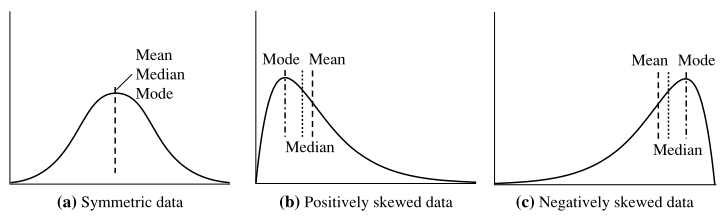

**The dispersion of data**:
- **Range**: is the difference between the largest and smallest values.
- **Quantiles**: are points taken at regular intervals of a data distribution, dividing it into essentially equal-size consecutive sets.

  Example: The 2-quantile is the data point dividing the lower and upper halves of the data distribution. It
  corresponds to the median. The 4-quantiles are the three data points that split the data distribution into
  four equal parts; each part represents one-fourth of the data distribution.

- The 100-quantiles are more commonly referred to as **percentiles**:

  0 percentile = 0 quartile (also called the minimum)<br>
  25th percentile = 1st quartile<br>
  50th percentile = 2nd quartile (also called the median)<br>
  75th percentile = 3rd quartile<br>
  100th percentile = 4th quartile (also called the maximum)<br>

  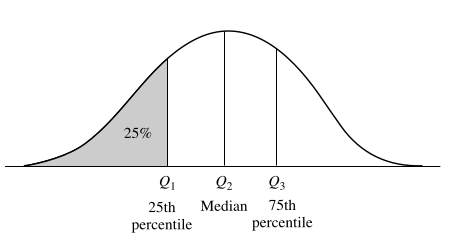

- **interquartile range** (IQR): The distance between the first and third quartiles is a simple measure of spread that gives the range covered by the middle half of the data.

\begin{align}
IQR = Q3 − Q1
\end{align}

- **Variance** and **standard deviation**: are measures of data dispersion. They indicate how spread out a data
distribution is. A low standard deviation means that the data observations tend to be very close to the
mean, whereas a high standard deviation indicates that the data are spread out over a large range of
values.

  The variance of N observations:

  \begin{align}
  σ^2 = \frac{1}{N} \sum_{i=1}^{N}(xi − x̄)^2
  \end{align}

  The standard deviation, σ, of the observations is the square root of the variance (is expressed in the same units as the variable).

We can take a summary of data spread in one chart called **BoxPlot**.

`Boxplots` are a popular way of visualizing a distribution. A boxplot incorporates the five-number
summary as follows:
- Typically, the ends of the box are at the quartiles so that the box length is the interquartile range.
- The median is marked by a line within the box.
- Two lines (called **whiskers**) outside the box extend to the smallest (Minimum) and largest (Maximum)
observations.

  The whiskers are extended to the extreme low and high observations only if these values are less than 1.5 × IQR beyond the quartiles. Otherwise, the whiskers terminate at the most extreme observations occurring within 1.5 × IQR of the quartiles. The remaining cases are plotted individually.

In [ ]:
fig = px.box(df, y="Age")
fig.update_layout(**layout_options)
fig.show()

In [ ]:
fig = px.box(df, y="Age", points="all")
fig.update_layout(**layout_options)
fig.show()

Few elderly passengers (<1%) within age range 66-80.

In [ ]:
fig = px.histogram(df, x="Age", color='Survived')
fig.update_layout(**layout_options)
fig.show()

- Age feature has a normal distribution with some spikes and bumps.
- babies (Age <=4) had high survival rate.
- Oldest passenger (Age = 80) survived.
- Most passengers are in 15-40 age range.


In [ ]:
fig = px.box(df, y="SibSp", points="all")
fig.update_layout(**layout_options)
fig.show()

The diagram is annoying with no clear info, Let's draw a histogram instead:

In [ ]:
fig = px.histogram(df, x="SibSp", color_discrete_sequence=['indianred'])
fig.update_layout(**layout_options)
fig.show()

Nearly 25% of the passengers had siblings and/or spouse aboard.

Let's see SibSp number and surviving relation:




In [ ]:
df[["SibSp", "Survived"]].groupby(['SibSp']).mean().sort_values(by='Survived', ascending=False)

,Survived
SibSp,
1,0.535885
2,0.464286
0,0.345395
3,0.250000
4,0.166667
5,0.000000
8,0.000000


In [ ]:
fig = px.histogram(df, x="Parch", color_discrete_sequence=['indianred'])
fig.update_layout(**layout_options)
fig.show()

Most passengers (> 75%) did not travel with parents or children.

In [ ]:
df[["Parch", "Survived"]].groupby(['Parch']).mean().sort_values(by='Survived', ascending=False)

,Survived
Parch,
3,0.600000
1,0.550847
2,0.500000
0,0.343658
5,0.200000
4,0.000000
6,0.000000
9,NaN


It seems from the last two charts that the person with smaller family size has more chance to survive.

In [ ]:
fig = px.box(df, y="Fare", points="all")
fig.update_layout(**layout_options)
fig.show()

Fares varied significantly with few passengers (<1%) paying as high as $512.

In [ ]:
fig = px.histogram(df, x="Fare", color='Survived')
fig.update_layout(**layout_options)
fig.show()

Higher fare paying passengers had better survival.

Let's see if there any relation between fare and other variables by visualization:

In [ ]:
fig = px.box(df, y='Fare', x='Pclass')
fig.update_layout(**layout_options)
fig.show()

In [ ]:
fig = px.box(df[df['Fare'] < 300], y='Fare', x='Pclass')
fig.update_layout(**layout_options)
fig.show()

In [ ]:
fig = px.box(df, y='Fare', x='Embarked')
fig.update_layout(**layout_options)
fig.show()

What about age? try to check or think about variables that have relations with the age:

In [ ]:
########################
#####YOUR CODE HERE#####
########################